<a href="https://colab.research.google.com/github/WayneNganju/D-10-Lab-on-Regression/blob/main/D10_farm_income_regression_~_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Team Introduction

This notebook was completed by Group D10 using the `farm_annual_income.csv` dataset to predict annual farm income.

The aim of this analysis is to identify farm characteristics that are useful for predicting annual farm income. The notebook follows a structured regression process, from understanding the data to building, evaluating, explaining, and saving the final prediction model.

The work was divided into connected stages so that each team member received the required output from the previous stage.

| Team Member | Student ID | Main Contribution |
|---|---:|---|
| Wayne Nganju | 146832 | As the team leader, I completed the Team Introduction, Environment Setup and Imports, Data Loading and Initial Data Understanding, Exploratory Data Analysis, and Train/Test Split sections.<br><br>I coordinated the handover of work between team members and completed the final integration of the notebook.|
| Vanessa Warui | 152142 | Vanessa received the train/test split data and completed Feature Selection.<br><br>She used correlation analysis, VIF, and RFECV to select the final features. |
| Natasha Njoroge | 150567 | Natasha received the selected features from Vanessa and created the preprocessing pipeline.<br><br>Her work included missing-value handling, categorical encoding, numeric scaling, and target transformation. |
| Ibrahim Omoi | 165042 | Ibrahim received the completed preprocessing pipeline from Natasha.<br><br>He compared regression models using cross-validation and evaluated them using the held-out test dataset. |
| Melvin Muriithi | 152384 | Melvin received the selected model and shared preprocessing pipeline.<br><br>He completed regression diagnostics, hyperparameter tuning, model explainability, and model persistence. |

The work was completed sequentially to prevent data leakage. As the team leader, I verified that the final narration was coherent and ran the notebook from top to bottom before submission. All team members reviewed the completed notebook and should understand the key modeling decisions made by the group.

## 1. Environment Setup and Imports

The analysis uses a fixed random seed so that the train/test split and all stochastic modeling steps can be reproduced.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "annual_farm_income_kes"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Python version: {sys.version.split()[0]}")
print(f"Target variable: {TARGET}")

Python version: 3.13.15
Target variable: annual_farm_income_kes


## 2. Data Loading

The Group D dataset is loaded directly from the course repository. This avoids depending on temporary files in a Colab session.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/course-files/RegressionAndClassification/main/data/farm_annual_income.csv"
)

farm_data = pd.read_csv(DATA_URL, encoding="utf-8")

if TARGET not in farm_data.columns:
    raise KeyError(
        f"Expected target '{TARGET}' was not found. Available columns: "
        f"{farm_data.columns.tolist()}"
    )

print(f"Dataset shape: {farm_data.shape[0]:,} rows and {farm_data.shape[1]:,} columns")
display(farm_data.head())

Dataset shape: 850 rows and 16 columns


,farm_id,crop_type,county,irrigation_type,cooperative_member,farm_size_acres,years_farming_experience,num_workers_employed,rainfall_mm,soil_quality_score,market_distance_km,machinery_value_kes,fertilizer_spend_kes,pesticide_spend_kes,irrigation_maintenance_cost_kes,annual_farm_income_kes
0,1,Tea,Uasin Gishu,Drip,No,7.26,10.0,1,1345.0,NaN,5.7,31304.0,22569.0,11598.0,20609.323557,240514.0
1,2,Tea,Nakuru,Drip,No,15.73,39.8,4,739.0,38.000299,11.3,156636.0,52716.0,13887.0,2849.905605,562457.0
2,3,Tea,Uasin Gishu,NaN,No,7.75,3.3,2,1101.0,57.136048,29.3,15966.0,28291.0,10697.0,NaN,176021.0
3,4,Coffee,Nakuru,NaN,No,3.90,30.6,1,831.0,73.593459,14.1,29920.0,16108.0,5383.0,NaN,283876.0
4,5,Tea,Kericho,Manual,No,10.49,9.3,1,967.0,54.498549,6.0,115136.0,28664.0,4486.0,3207.355224,242651.0


In [3]:
farm_data.info()

print("\nColumn names:")
print(farm_data.columns.tolist())

print(f"\nSummary of {TARGET}:")
display(farm_data[TARGET].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   farm_id                          850 non-null    int64  
 1   crop_type                        850 non-null    object 
 2   county                           850 non-null    object 
 3   irrigation_type                  547 non-null    object 
 4   cooperative_member               850 non-null    object 
 5   farm_size_acres                  850 non-null    float64
 6   years_farming_experience         850 non-null    float64
 7   num_workers_employed             850 non-null    int64  
 8   rainfall_mm                      850 non-null    float64
 9   soil_quality_score               807 non-null    float64
 10  market_distance_km               850 non-null    float64
 11  machinery_value_kes              850 non-null    float64
 12  fertilizer_spend_kes  

,annual_farm_income_kes
count,8.500000e+02
mean,2.686471e+05
std,1.608326e+05
min,5.653400e+04
25%,1.683308e+05
50%,2.237460e+05
75%,3.279118e+05
max,2.060104e+06


### Initial Data Understanding

This dataset has 16 columns and 850 observations. The target variable is `annual_farm_income_kes`, which gives the annual income of each farm in Kenyan shillings (KES).

The data contains an ID column called `farm_id`, categorical columns such as `crop_type`, `county`, `irrigation_type`, and `cooperative_member`, and numeric columns containing operational, environmental, and financial data. Some examples of numeric predictors are the number of workers on the farm, farm size, farming experience, irrigation maintenance cost, fertilizer expenditure, pesticide expenditure, market distance, soil quality, and the value of machinery.

As seen in the preview, some variables, such as `soil_quality_score`, `irrigation_type`, and `irrigation_maintenance_cost_kes`, have missing values. The reasons for this missing data should be studied during exploratory data analysis before selecting a suitable data preprocessing method. The `farm_id` column is not a meaningful farm characteristic and will therefore not be used for predictive modeling after the train/test split.

## 3. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the variables in the dataset before building any regression model. In this section, we examine the types of variables, missing values, distributions, potential outliers, and the relationships between numeric predictors and annual farm income.

The original `farm_data` DataFrame is used in this section. No variables are removed, transformed, encoded, imputed, or used to train a model at this stage.

In [4]:
numeric_cols = farm_data.select_dtypes(include=np.number).columns.tolist()

categorical_cols = farm_data.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

missingness = (
    farm_data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_pct=lambda frame: (
            frame["missing_count"] / len(farm_data) * 100
        )
    )
    .sort_values("missing_pct", ascending=False)
)

display(missingness)

Numeric columns:
['farm_id', 'farm_size_acres', 'years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'machinery_value_kes', 'fertilizer_spend_kes', 'pesticide_spend_kes', 'irrigation_maintenance_cost_kes', 'annual_farm_income_kes']

Categorical columns:
['crop_type', 'county', 'irrigation_type', 'cooperative_member']


,missing_count,missing_pct
irrigation_type,303,35.647059
irrigation_maintenance_cost_kes,303,35.647059
soil_quality_score,43,5.058824
farm_id,0,0.000000
cooperative_member,0,0.000000
farm_size_acres,0,0.000000
crop_type,0,0.000000
county,0,0.000000
num_workers_employed,0,0.000000
years_farming_experience,0,0.000000


### Variable Types and Missing Values

The dataset has 12 numeric columns and 4 categorical columns. One numeric column, `farm_id`, is an identifier and will not be used as a predictive feature after the train/test split. The remaining numeric columns include farm size, farming experience, number of workers, rainfall, soil quality, market distance, machinery value, farm expenditures, and annual farm income. The categorical columns describe the crop grown, county, irrigation type, and cooperative membership.

There are missing values in three variables. Both `irrigation_type` and `irrigation_maintenance_cost_kes` have 303 missing values, representing 35.65% of the dataset. Since these variables have the same number of missing values, their missingness may be related. `soil_quality_score` has 43 missing values, representing 5.06% of the dataset.

At this stage, no missing values are imputed. The relationship between the irrigation variables will first be examined to determine whether their missingness is structural or random. Any imputation method will later be fitted using training data only.

In [5]:
irrigation_missingness_check = pd.crosstab(
    farm_data["irrigation_type"].isna(),
    farm_data["irrigation_maintenance_cost_kes"].isna(),
    margins=True
)

irrigation_missingness_check.index = [
    "Irrigation type observed",
    "Irrigation type missing",
    "Total"
]

irrigation_missingness_check.columns = [
    "Maintenance cost observed",
    "Maintenance cost missing",
    "Total"
]

display(irrigation_missingness_check)

print("Irrigation type categories where maintenance cost is observed:")
display(
    farm_data.loc[
        farm_data["irrigation_maintenance_cost_kes"].notna(),
        "irrigation_type"
    ].value_counts(dropna=False)
)

,Maintenance cost observed,Maintenance cost missing,Total
Irrigation type observed,547,0,547
Irrigation type missing,0,303,303
Total,547,303,850


Irrigation type categories where maintenance cost is observed:


,count
irrigation_type,
Manual,225
Drip,198
Automated,124


### **Irrigation Missingness Check**

The missing values in `irrigation_type` and `irrigation_maintenance_cost_kes` occur together for the same 303 farms. All 547 farms with an observed irrigation type also have an observed irrigation maintenance cost. Similarly, every farm with a missing irrigation type has a missing irrigation maintenance cost.

This pattern suggests that the missing values are not random. It is likely that these farms do not use a recorded irrigation method, and therefore do not have an irrigation maintenance cost. This is likely to be structural missingness because the maintenance cost may not apply to farms without irrigation.

Among farms with observed irrigation information, 225 use manual irrigation, 198 use drip irrigation, and 124 use automated irrigation. During preprocessing, the irrigation-related missing values should be handled carefully so that the model can retain information about farms with no recorded irrigation.

### Distribution of Numeric Variables

The numeric variables are examined using measures of central tendency and distribution. These include the minimum value, lower quartile, median, upper quartile, maximum value, mean, standard deviation, skewness, and kurtosis.

Skewness helps to show whether a variable is distributed symmetrically or has a long tail on one side. Kurtosis helps to show whether a variable has unusually heavy tails or extreme values. These results will help to identify variables that may require transformation or further investigation.

In [6]:
numeric_cols_without_id = [
    column for column in numeric_cols
    if column != "farm_id"
]

q1 = farm_data[numeric_cols_without_id].quantile(0.25)
q2 = farm_data[numeric_cols_without_id].quantile(0.50)
q3 = farm_data[numeric_cols_without_id].quantile(0.75)

distribution_summary = pd.DataFrame(
    {
        "minimum": farm_data[numeric_cols_without_id].min(),
        "q1_25%": q1,
        "median_q2_50%": q2,
        "q3_75%": q3,
        "maximum": farm_data[numeric_cols_without_id].max(),
        "mean": farm_data[numeric_cols_without_id].mean(),
        "standard_deviation": farm_data[numeric_cols_without_id].std(),
        "skewness": farm_data[numeric_cols_without_id].skew(),
        "kurtosis": farm_data[numeric_cols_without_id].kurt(),
    }
)

display(distribution_summary.round(2))

,minimum,q1_25%,median_q2_50%,q3_75%,maximum,mean,standard_deviation,skewness,kurtosis
farm_size_acres,0.5,3.90,6.34,10.09,31.44,7.68,5.15,1.19,1.40
years_farming_experience,0.5,6.72,11.40,17.70,45.00,13.37,8.86,1.25,1.56
num_workers_employed,0.0,1.00,2.00,3.00,9.00,2.03,1.68,0.76,0.26
rainfall_mm,250.0,800.00,951.00,1091.75,1566.00,946.02,218.53,0.02,-0.08
soil_quality_score,5.0,49.73,61.61,73.89,100.00,61.63,17.18,-0.16,-0.12
market_distance_km,1.0,8.10,13.65,22.20,68.50,16.39,11.50,1.27,1.81
machinery_value_kes,0.0,29763.50,56409.50,95019.00,350170.00,69103.23,55154.40,1.31,1.92
fertilizer_spend_kes,1104.0,11143.00,19577.00,33529.00,133274.00,24391.90,18199.56,1.58,3.73
pesticide_spend_kes,199.0,4718.25,8587.50,13805.25,50169.00,10560.84,8272.50,1.63,3.43
irrigation_maintenance_cost_kes,500.0,4057.64,7532.92,12234.66,36866.42,8994.86,6353.07,1.30,2.00


The target variable, `annual_farm_income_kes`, has a mean of 268,647.10 KES and a median of 223,746.00 KES. Since the mean is higher than the median, this suggests that some farms have relatively high annual incomes which increase the average income.

The annual farm income ranges from 56,534.00 KES to 2,060,104.00 KES. Its skewness is 3.38, which shows that the target is strongly skewed to the right. Its kurtosis is 23.58, which suggests that there are extreme income values in the upper end of the distribution.

Most of the expenditure and machinery variables are also positively skewed. In particular, `fertilizer_spend_kes` and `pesticide_spend_kes` have skewness values above 1.5 and relatively high kurtosis values. This indicates that a small number of farms have much higher expenditure levels than most farms.

Since `annual_farm_income_kes` is strictly positive and strongly right-skewed, a `log1p` transformation will later be considered for the target variable. This transformation can reduce the influence of very high income values during model training.

### Distribution of Annual Farm Income

The distribution of the target variable is examined using a histogram and a boxplot. The histogram shows the general shape of annual farm income, while the boxplot helps to identify possible extreme income values.

This is important because regression models can be affected when the target variable is strongly skewed or contains extreme observations.

Target skewness: 3.379
Target kurtosis: 23.576
Target minimum: 56,534.00 KES
Target maximum: 2,060,104.00 KES


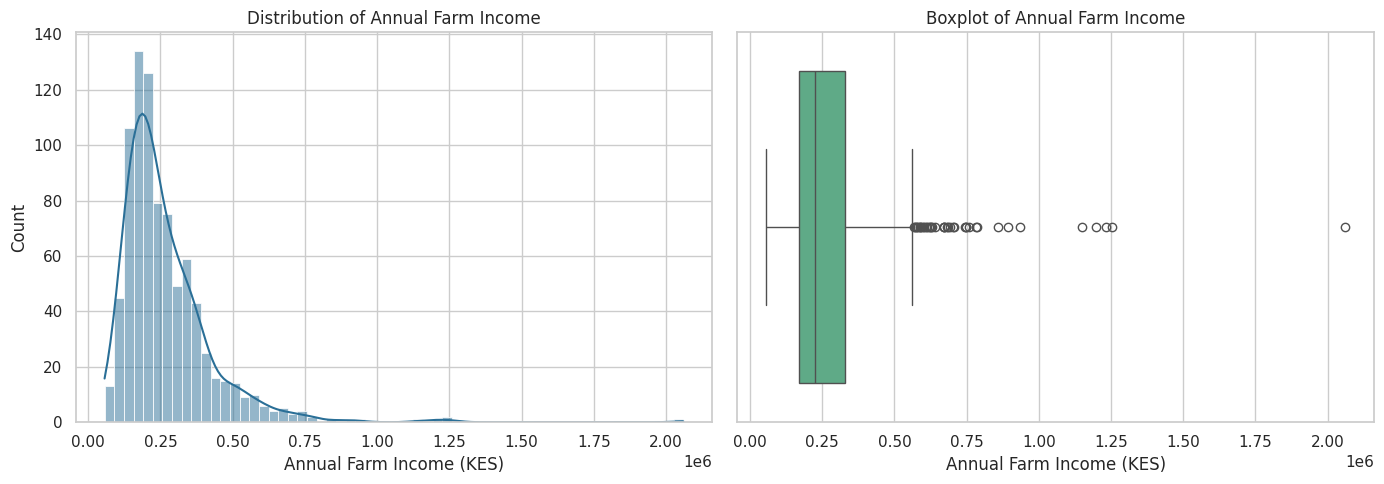

In [7]:
target_skewness = farm_data[TARGET].skew()
target_kurtosis = farm_data[TARGET].kurt()

print(f"Target skewness: {target_skewness:.3f}")
print(f"Target kurtosis: {target_kurtosis:.3f}")
print(f"Target minimum: {farm_data[TARGET].min():,.2f} KES")
print(f"Target maximum: {farm_data[TARGET].max():,.2f} KES")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(farm_data[TARGET], kde=True, ax=axes[0], color="#2A6F97")
axes[0].set_title("Distribution of Annual Farm Income")
axes[0].set_xlabel("Annual Farm Income (KES)")

sns.boxplot(x=farm_data[TARGET], ax=axes[1], color="#52B788")
axes[1].set_title("Boxplot of Annual Farm Income")
axes[1].set_xlabel("Annual Farm Income (KES)")

plt.tight_layout()
plt.show()

The annual farm income ranges from 56,534.00 KES to 2,060,104.00 KES. The target has a skewness of 3.38 and a kurtosis of 23.58. This shows that annual farm income is strongly skewed to the right and has some extreme high-income farms.

The histogram shows that most farms have lower to moderate annual incomes, while a small number of farms have much higher incomes. The boxplot also shows potential high-income outliers.

Since `annual_farm_income_kes` is strictly positive and strongly right-skewed, a `log1p` transformation will later be considered before modeling. This transformation can reduce the effect of very high farm incomes and make the target distribution more suitable for regression modeling.

### Potential Outliers

The interquartile range (IQR) method is used to identify possible outliers in the numeric variables. A value is considered a potential outlier when it is below the lower fence or above the upper fence.

The lower fence is calculated as:

$Q1 - 1.5 \times IQR$

The upper fence is calculated as:

$Q3 + 1.5 \times IQR$

Potential outliers will be investigated, but they will not be automatically removed because unusually large farms, high expenditure values, or high farm incomes may be valid observations.

In [8]:
q1 = farm_data[numeric_cols_without_id].quantile(0.25)
q3 = farm_data[numeric_cols_without_id].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = (
    (farm_data[numeric_cols_without_id] < lower_fence)
    | (farm_data[numeric_cols_without_id] > upper_fence)
)

outlier_summary = pd.DataFrame(
    {
        "potential_outlier_count": outlier_mask.sum(),
        "potential_outlier_pct": (
            outlier_mask.sum() / len(farm_data) * 100
        ),
    }
).sort_values("potential_outlier_count", ascending=False)

display(outlier_summary.round(2))

,potential_outlier_count,potential_outlier_pct
annual_farm_income_kes,39,4.59
pesticide_spend_kes,37,4.35
farm_size_acres,35,4.12
machinery_value_kes,34,4.00
years_farming_experience,31,3.65
market_distance_km,30,3.53
fertilizer_spend_kes,28,3.29
irrigation_maintenance_cost_kes,16,1.88
num_workers_employed,10,1.18
rainfall_mm,5,0.59


### Relationships Between Numeric Variables and Annual Farm Income

Pearson correlation is used to measure linear relationships between numeric variables and annual farm income. Spearman correlation is also used because it can identify monotonic relationships that may not be perfectly linear.

Comparing the Pearson and Spearman correlation values helps to identify variables where the relationship with annual farm income may be non-linear. Correlation results will guide later feature selection, but they do not show that one variable causes another variable to change.

In [9]:
correlation_cols = [
    column for column in numeric_cols_without_id
    if column != TARGET
]

pearson_corr = (
    farm_data[correlation_cols + [TARGET]]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
)

spearman_corr = (
    farm_data[correlation_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
)

relationship_summary = pd.DataFrame(
    {
        "pearson_correlation": pearson_corr,
        "spearman_correlation": spearman_corr,
    }
)

relationship_summary["absolute_difference"] = (
    relationship_summary["pearson_correlation"]
    - relationship_summary["spearman_correlation"]
).abs()

relationship_summary = relationship_summary.sort_values(
    "pearson_correlation",
    key=abs,
    ascending=False
)

display(relationship_summary.round(3))

,pearson_correlation,spearman_correlation,absolute_difference
years_farming_experience,0.528,0.512,0.016
soil_quality_score,0.128,0.160,0.031
market_distance_km,-0.071,-0.070,0.001
rainfall_mm,0.057,0.118,0.062
num_workers_employed,0.048,0.047,0.001
irrigation_maintenance_cost_kes,0.026,0.055,0.029
pesticide_spend_kes,-0.010,-0.002,0.009
farm_size_acres,0.010,-0.002,0.012
fertilizer_spend_kes,0.008,0.001,0.007
machinery_value_kes,0.003,-0.010,0.013


`years_farming_experience` has the strongest relationship with annual farm income. It has a Pearson correlation of 0.528 and a Spearman correlation of 0.512. This shows a moderate positive relationship, meaning that farms managed by people with more farming experience tend to have higher annual incomes.

`soil_quality_score` has a weak positive relationship with annual farm income, with a Pearson correlation of 0.128. This suggests that farms with better soil quality may tend to earn slightly higher incomes. `rainfall_mm` also has a weak positive relationship, with a Pearson correlation of 0.057 and a Spearman correlation of 0.118.

`market_distance_km` has a weak negative relationship with annual farm income, with a Pearson correlation of -0.071. This suggests that farms located farther from markets may tend to have slightly lower incomes.

The remaining numeric variables have very weak linear relationships with annual farm income. In particular, farm size, machinery value, fertilizer expenditure, and pesticide expenditure have Pearson correlations close to zero. This does not mean that these variables are useless for prediction, because they may have non-linear relationships or may become useful when combined with other variables in a machine learning model.

The Pearson and Spearman values are generally similar. However, the difference for `rainfall_mm` is 0.062, which suggests that its relationship with annual farm income may not be completely linear.

### Correlation Heatmap

A Pearson correlation heatmap is used to examine the relationships among all numeric variables. This helps to identify variables that are highly correlated with each other.

Highly correlated predictors may cause multicollinearity in linear regression models. These variables will be examined again after the train/test split during the feature selection stage.

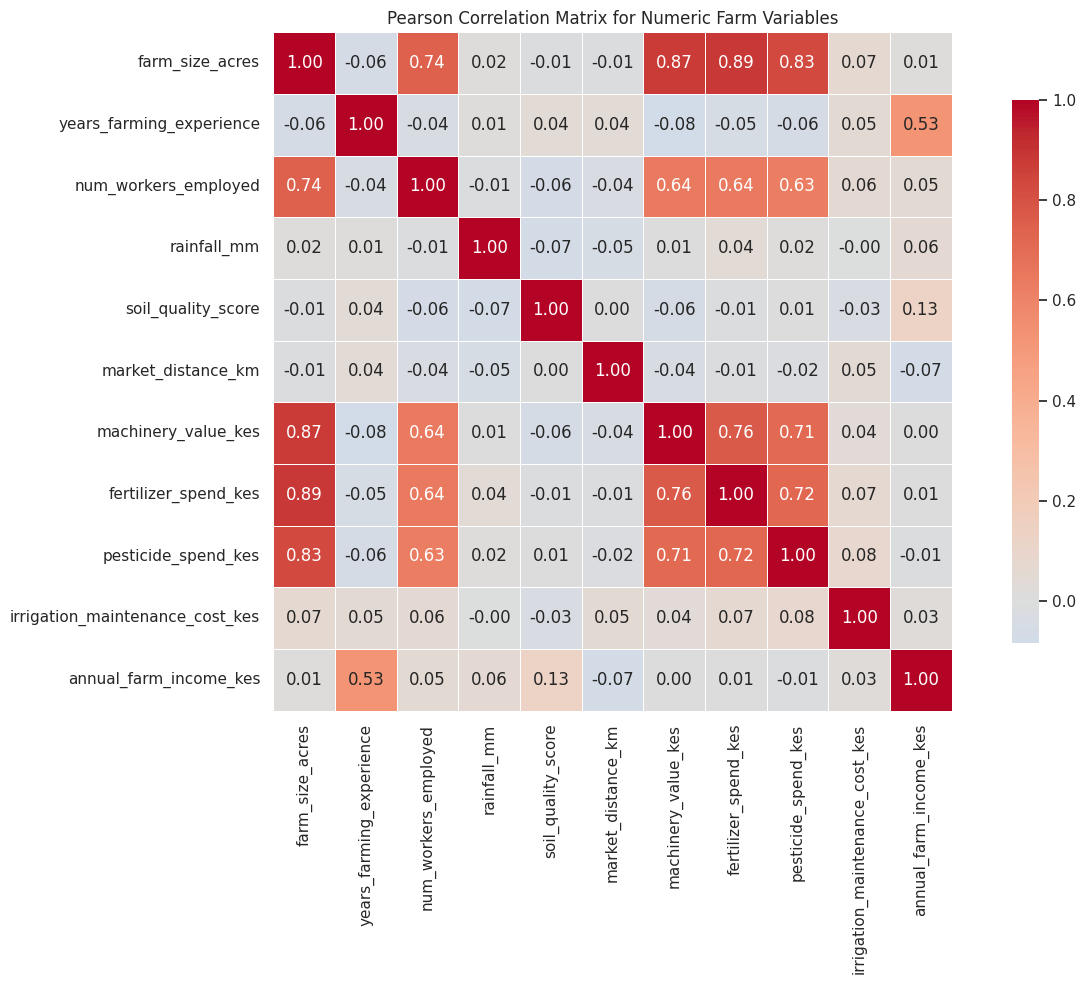

In [10]:
heatmap_columns = [
    column for column in numeric_cols
    if column != "farm_id"
]

correlation_matrix = farm_data[heatmap_columns].corr(method="pearson")

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix for Numeric Farm Variables")
plt.tight_layout()
plt.show()

## 4. Train/Test Split

The dataset is split into training data and test data before feature selection and preprocessing. This is important because fitting scalers, encoders, imputers, or feature-selection methods on the full dataset would allow information from the test data to influence the training process. This is known as data leakage and can produce overly optimistic model performance results.

In this analysis, 80% of the data will be used for training and 20% will be used for testing. Since annual farm income is strongly right-skewed, the target variable is divided into quantile-based groups before splitting. This helps to ensure that both the training and test datasets contain a similar mix of lower-, middle-, and higher-income farms.

In [11]:
from sklearn.model_selection import train_test_split

# Income groups are created only to stratify the split.
# They are not used as model features.
income_bins = pd.qcut(
    farm_data[TARGET],
    q=5,
    labels=False,
    duplicates="drop"
)

# farm_id is an identifier, so it is excluded from model features.
feature_cols = [
    column for column in farm_data.columns
    if column not in ["farm_id", TARGET]
]

X = farm_data[feature_cols].copy()
y = farm_data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=income_bins
)

print(f"Training data: {X_train.shape[0]} rows and {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]} rows and {X_test.shape[1]} features")
print(f"Training income mean: {y_train.mean():,.2f} KES")
print(f"Test income mean: {y_test.mean():,.2f} KES")

Training data: 680 rows and 14 features
Test data: 170 rows and 14 features
Training income mean: 269,284.10 KES
Test income mean: 266,099.13 KES


The dataset was split into 680 training observations and 170 test observations. Both datasets contain 14 predictor variables. The `farm_id` column was excluded because it is an identifier, while `annual_farm_income_kes` was separated as the target variable.

The data was split using an 80:20 ratio. The training data will be used to select features, fit preprocessing steps, train models, and tune hyperparameters. The test data will remain untouched until the final evaluation stage.

Since annual farm income is strongly right-skewed, quantile-based income groups were used to stratify the split. This helps to ensure that both the training and test datasets contain a similar mix of lower-, middle-, and higher-income farms. The similar training and test income means also suggest that the split preserved the general income distribution.

## 5. Feature Selection

Feature selection is performed using the training data only. This helps to identify redundant or weak predictor variables before modeling while keeping the test data untouched for final evaluation.

In this section, correlation-based filtering, the Variance Inflation Factor (VIF), and Recursive Feature Elimination with Cross-Validation (RFECV) are used to examine the numeric predictors. Highly correlated predictors can create multicollinearity, which can make linear regression coefficients unstable and difficult to interpret.

In [12]:
numeric_train = X_train.select_dtypes(include=np.number).copy()

train_correlation_matrix = numeric_train.corr(method="pearson").abs()

high_correlation_pairs = []

for first_index in range(len(train_correlation_matrix.columns)):
    for second_index in range(first_index + 1, len(train_correlation_matrix.columns)):
        correlation_value = train_correlation_matrix.iloc[
            first_index,
            second_index
        ]

        if correlation_value > 0.80:
            high_correlation_pairs.append(
                {
                    "feature_1": train_correlation_matrix.columns[first_index],
                    "feature_2": train_correlation_matrix.columns[second_index],
                    "absolute_correlation": round(correlation_value, 3),
                }
            )

high_correlation_pairs_df = pd.DataFrame(high_correlation_pairs)

if high_correlation_pairs_df.empty:
    print("No numeric predictor pairs have an absolute correlation above 0.80.")
else:
    display(
        high_correlation_pairs_df.sort_values(
            "absolute_correlation",
            ascending=False
        )
    )

,feature_1,feature_2,absolute_correlation
1,farm_size_acres,fertilizer_spend_kes,0.884
0,farm_size_acres,machinery_value_kes,0.876
2,farm_size_acres,pesticide_spend_kes,0.835


### Correlation-Based Feature Selection

The training-data correlation analysis identified three pairs of numeric predictors with an absolute Pearson correlation above 0.80. All three pairs involve `farm_size_acres`.

`farm_size_acres` has a strong positive correlation with `fertilizer_spend_kes` (0.884), `machinery_value_kes` (0.876), and `pesticide_spend_kes` (0.835). This is expected because larger farms may require more machinery and higher expenditure on farm inputs.

These variables may contain overlapping information. However, they will not be removed based on correlation alone. The Variance Inflation Factor (VIF) will be used next to confirm whether these relationships create high multicollinearity in the regression model.

### Variance Inflation Factor

The Variance Inflation Factor (VIF) is used to measure multicollinearity among numeric predictors. A high VIF indicates that a predictor can be explained by other predictors in the dataset.

A VIF above 5 may require investigation, while a VIF above 10 is commonly treated as strong evidence of multicollinearity. Since VIF requires a complete numeric dataset, median imputation is used only for this diagnostic calculation. This diagnostic imputation is separate from the final preprocessing pipeline.

In [13]:
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# No variables are removed yet. VIF will guide the final decision.
X_train_corr = X_train.copy()
X_test_corr = X_test.copy()

numeric_train_corr = X_train_corr.select_dtypes(include=np.number).copy()

vif_imputer = SimpleImputer(strategy="median")
numeric_train_for_vif = vif_imputer.fit_transform(numeric_train_corr)

vif_results = pd.DataFrame(
    {
        "feature": numeric_train_corr.columns,
        "VIF": [
            variance_inflation_factor(
                numeric_train_for_vif,
                index
            )
            for index in range(numeric_train_for_vif.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)

display(vif_results.round(2))

,feature,VIF
0,farm_size_acres,41.94
7,fertilizer_spend_kes,13.03
6,machinery_value_kes,11.33
3,rainfall_mm,10.44
4,soil_quality_score,9.43
8,pesticide_spend_kes,8.93
2,num_workers_employed,5.60
9,irrigation_maintenance_cost_kes,3.49
1,years_farming_experience,3.29
5,market_distance_km,2.91


**VIF Feature Selection Decision**

The VIF results show that `farm_size_acres` has a very high VIF of 41.94. It also has strong correlations with `fertilizer_spend_kes`, `machinery_value_kes`, and `pesticide_spend_kes`.

Therefore, `farm_size_acres` is removed from the predictor data. This reduces overlapping information because farm size is strongly related to the amount spent on machinery, fertilizer, and pesticides. The expenditure variables are retained because they provide more specific information about farm operations and investment.

`rainfall_mm` has a VIF of 10.44 and will be reviewed after removing `farm_size_acres`. VIF values will be recalculated before deciding whether any further variables should be removed.

In [14]:
columns_to_drop_vif = [
    "farm_size_acres"
]

X_train_vif = X_train_corr.drop(
    columns=columns_to_drop_vif,
    errors="ignore"
).copy()

X_test_vif = X_test_corr.drop(
    columns=columns_to_drop_vif,
    errors="ignore"
).copy()

numeric_train_vif = X_train_vif.select_dtypes(
    include=np.number
).copy()

vif_imputer_recheck = SimpleImputer(strategy="median")

numeric_train_for_vif_recheck = vif_imputer_recheck.fit_transform(
    numeric_train_vif
)

vif_results_recheck = pd.DataFrame(
    {
        "feature": numeric_train_vif.columns,
        "VIF": [
            variance_inflation_factor(
                numeric_train_for_vif_recheck,
                index
            )
            for index in range(
                numeric_train_for_vif_recheck.shape[1]
            )
        ],
    }
).sort_values("VIF", ascending=False)

display(vif_results_recheck.round(2))

,feature,VIF
2,rainfall_mm,10.44
3,soil_quality_score,9.40
6,fertilizer_spend_kes,8.46
5,machinery_value_kes,7.55
7,pesticide_spend_kes,6.85
1,num_workers_employed,4.91
8,irrigation_maintenance_cost_kes,3.49
0,years_farming_experience,3.28
4,market_distance_km,2.90


**VIF Recheck and Final Multicollinearity Decision**

After removing `farm_size_acres`, the VIF values reduced substantially. The highest remaining VIF is for `rainfall_mm` at 10.44. Although this value is above the common investigation threshold, rainfall is an important environmental variable and was not strongly correlated with any single numeric predictor in the earlier correlation analysis.

The remaining expenditure variables have moderate VIF values. However, they measure different aspects of farm investment, including machinery, fertilizer, and pesticide expenditure. Therefore, no further variables are removed based on VIF at this stage.

The final selection of numeric variables will be examined using Recursive Feature Elimination with Cross-Validation (RFECV). This method selects variables based on their contribution to prediction performance.

### Recursive Feature Elimination With Cross-Validation

Recursive Feature Elimination with Cross-Validation (RFECV) is used as an additional feature-selection method. RFECV repeatedly fits a linear regression model and removes weaker numeric predictors until it identifies a suitable number of features using cross-validation.

RFECV is performed using training data only. Categorical variables are retained because they will be handled later using encoding in the preprocessing pipeline.

In [15]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

numeric_train_vif = X_train_vif.select_dtypes(
    include=np.number
).copy()

numeric_feature_names = numeric_train_vif.columns.tolist()

rfecv_imputer = SimpleImputer(strategy="median")

numeric_train_imputed = rfecv_imputer.fit_transform(
    numeric_train_vif
)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rfecv_selector = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    min_features_to_select=1
)

rfecv_selector.fit(
    numeric_train_imputed,
    y_train
)

rfecv_results = pd.DataFrame(
    {
        "feature": numeric_feature_names,
        "selected": rfecv_selector.support_,
        "rank": rfecv_selector.ranking_,
    }
).sort_values(
    ["selected", "rank"],
    ascending=[False, True]
)

print(
    f"Optimal number of numeric features: "
    f"{rfecv_selector.n_features_}"
)

display(rfecv_results)

Optimal number of numeric features: 6


,feature,selected,rank
0,years_farming_experience,True,1
1,num_workers_employed,True,1
2,rainfall_mm,True,1
3,soil_quality_score,True,1
4,market_distance_km,True,1
7,pesticide_spend_kes,True,1
8,irrigation_maintenance_cost_kes,False,2
6,fertilizer_spend_kes,False,3
5,machinery_value_kes,False,4


**RFECV Feature Selection Decision**

RFECV selected six numeric predictors as the most useful set for predicting annual farm income. The selected variables are `years_farming_experience`, `num_workers_employed`, `rainfall_mm`, `soil_quality_score`, `market_distance_km`, and `pesticide_spend_kes`.

The results suggest that farming experience, labour, environmental conditions, soil quality, access to markets, and pesticide expenditure provide useful information for predicting annual farm income.

RFECV did not select `irrigation_maintenance_cost_kes`, `fertilizer_spend_kes`, or `machinery_value_kes`. These variables were excluded because they did not improve the cross-validated performance of the linear regression model as much as the selected variables.

The categorical variables, `crop_type`, `county`, `irrigation_type`, and `cooperative_member`, are retained because they will be encoded during the preprocessing stage. The feature-selection decisions were made using the training data only.

In [16]:
selected_numeric_features = [
    feature
    for feature, selected in zip(
        numeric_feature_names,
        rfecv_selector.support_
    )
    if selected
]

categorical_features = X_train_vif.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

selected_features = (
    selected_numeric_features
    + categorical_features
)

X_train_selected = X_train_vif[
    selected_features
].copy()

X_test_selected = X_test_vif[
    selected_features
].copy()

print("Selected numeric features:")
print(selected_numeric_features)

print("\nRetained categorical features:")
print(categorical_features)

print("\nFinal selected features:")
print(selected_features)

print(
    f"\nTraining data after feature selection: "
    f"{X_train_selected.shape[0]} rows and "
    f"{X_train_selected.shape[1]} features"
)

print(
    f"Test data after feature selection: "
    f"{X_test_selected.shape[0]} rows and "
    f"{X_test_selected.shape[1]} features"
)

Selected numeric features:
['years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'pesticide_spend_kes']

Retained categorical features:
['crop_type', 'county', 'irrigation_type', 'cooperative_member']

Final selected features:
['years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'pesticide_spend_kes', 'crop_type', 'county', 'irrigation_type', 'cooperative_member']

Training data after feature selection: 680 rows and 10 features
Test data after feature selection: 170 rows and 10 features


## 6. Preprocessing and Target Transformation

Data preprocessing is performed after feature selection and uses the training data only. The preprocessing pipeline will handle missing values, categorical variables, and differences in scale between numeric variables.

The same fitted preprocessing steps will later be applied to both training and test data through a pipeline. This prevents data leakage and ensures that every regression model receives data in the same format.

### Missing Data and Categorical Variables

`soil_quality_score` has a small number of missing values. Since soil quality is a numeric variable, median imputation will be used to replace its missing values.

`irrigation_type` has structural missingness because farms with no recorded irrigation type also have no recorded irrigation maintenance cost. Since `irrigation_maintenance_cost_kes` was not selected by RFECV, only `irrigation_type` remains in the selected features. Its missing values will be replaced with the category `Not recorded` rather than the most common irrigation type. This preserves information that the irrigation type was not recorded.

The categorical variables `crop_type`, `county`, `irrigation_type`, and `cooperative_member` will be one-hot encoded. The numeric variables will be standardized so that they have a comparable scale for models such as Ridge, Lasso, and ElasticNet regression.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train_selected.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train_selected.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Not recorded"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nPreprocessing pipeline constructed successfully.")

Numeric features:
['years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'pesticide_spend_kes']

Categorical features:
['crop_type', 'county', 'irrigation_type', 'cooperative_member']

Preprocessing pipeline constructed successfully.


### Target Transformation

The target variable, `annual_farm_income_kes`, is strictly positive and strongly right-skewed. Therefore, a `log1p` transformation is applied to the target before model training.

The `log1p` transformation calculates the natural logarithm of one plus the income value. It reduces the influence of extremely high-income farms and can make the target distribution more suitable for regression modeling. Predictions will later be converted back to Kenyan shillings using `np.expm1()`.

Training target skewness before log1p: 3.628
Training target skewness after log1p: 0.450


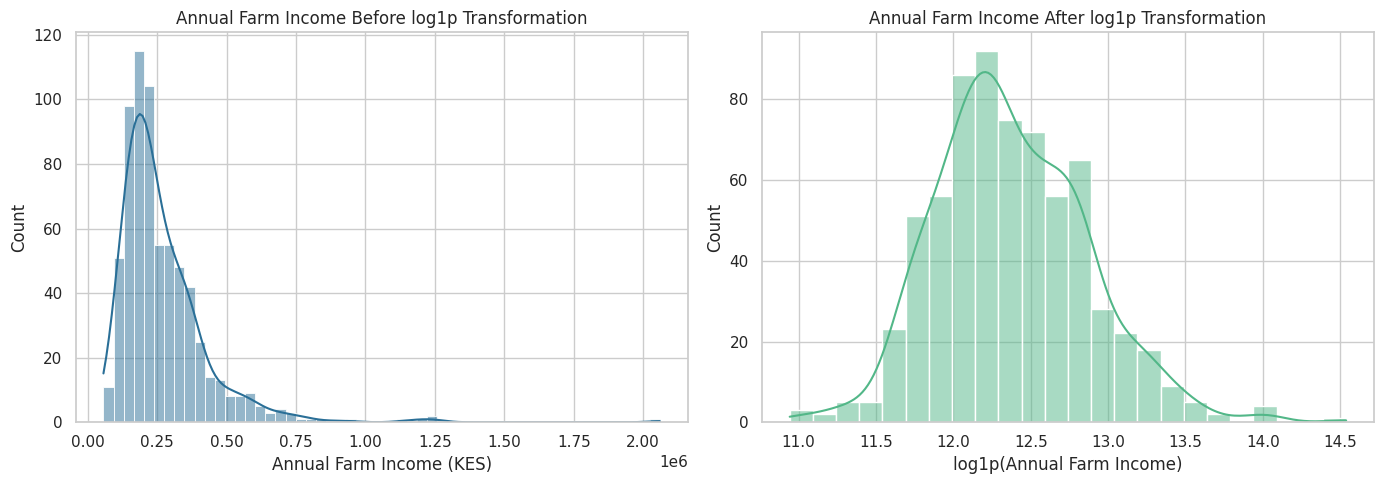

In [18]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"Training target skewness before log1p: {y_train.skew():.3f}")
print(f"Training target skewness after log1p: {y_train_log.skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    y_train,
    kde=True,
    ax=axes[0],
    color="#2A6F97"
)
axes[0].set_title("Annual Farm Income Before log1p Transformation")
axes[0].set_xlabel("Annual Farm Income (KES)")

sns.histplot(
    y_train_log,
    kde=True,
    ax=axes[1],
    color="#52B788"
)
axes[1].set_title("Annual Farm Income After log1p Transformation")
axes[1].set_xlabel("log1p(Annual Farm Income)")

plt.tight_layout()
plt.show()

### Preprocessing and Target Transformation Summary

The preprocessing pipeline handles numeric and categorical variables using the selected training features. Missing numeric values, including missing soil quality scores, are replaced using the median value from the training data. Numeric variables are then standardized so that models such as Ridge, Lasso, and ElasticNet can treat their scales fairly.

The categorical variables are imputed using the category `Not recorded` and are then one-hot encoded. This is particularly important for `irrigation_type`, where the missing values occur together with missing irrigation maintenance costs and may represent farms with no recorded irrigation information.

The target variable, `annual_farm_income_kes`, is transformed using `log1p` because it is strictly positive and strongly right-skewed. The transformation reduces the influence of very high-income farms during model training. Later, predicted values will be converted back to Kenyan shillings using `np.expm1()`.

In [19]:
X_train_processed = preprocessor.fit_transform(
    X_train_selected
)

X_test_processed = preprocessor.transform(
    X_test_selected
)

print(
    f"Processed training data shape: "
    f"{X_train_processed.shape}"
)

print(
    f"Processed test data shape: "
    f"{X_test_processed.shape}"
)

assert (
    X_train_processed.shape[1]
    == X_test_processed.shape[1]
), "Training and test data must have the same number of processed features."

print(
    "Preprocessing check passed: training and test data "
    "have the same processed feature structure."
)

Processed training data shape: (680, 23)
Processed test data shape: (170, 23)
Preprocessing check passed: training and test data have the same processed feature structure.


## 7. Modeling and Cross-Validation

Several regression models are compared using the same preprocessing pipeline and 5-fold cross-validation. This allows the models to be evaluated fairly because each model receives the same selected features, missing-value treatment, categorical encoding, and numeric scaling.

The models are trained using the log-transformed target variable, `y_train_log`. Cross-validation is performed using the training data only. The evaluation metric is root mean squared error (RMSE) on the log scale, where a lower value indicates better prediction performance.

In [20]:
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(
        alpha=0.01,
        max_iter=20000,
        random_state=RANDOM_STATE
    ),
    "ElasticNet Regression": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=20000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=6,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        n_jobs=1,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
}

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"Models to compare: {list(models.keys())}")
print("Cross-validation method: 5-fold K-Fold")
print("Metric: RMSE on the log-transformed income scale")

Models to compare: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Cross-validation method: 5-fold K-Fold
Metric: RMSE on the log-transformed income scale


In [21]:
cv_results = []
model_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = -cross_val_score(
        pipeline,
        X_train_selected,
        y_train_log,
        cv=kfold,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    model_pipelines[model_name] = pipeline

    cv_results.append(
        {
            "model": model_name,
            "mean_cv_rmse_log": scores.mean(),
            "std_cv_rmse_log": scores.std(),
        }
    )

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("mean_cv_rmse_log")
    .reset_index(drop=True)
)

display(cv_results_df.round(4))

,model,mean_cv_rmse_log,std_cv_rmse_log
0,Ridge Regression,0.3236,0.0357
1,Linear Regression,0.3237,0.0357
2,ElasticNet Regression,0.3253,0.0338
3,Lasso Regression,0.3299,0.0327
4,Gradient Boosting,0.3461,0.0304
5,Random Forest,0.3598,0.0287
6,Decision Tree,0.4402,0.0149


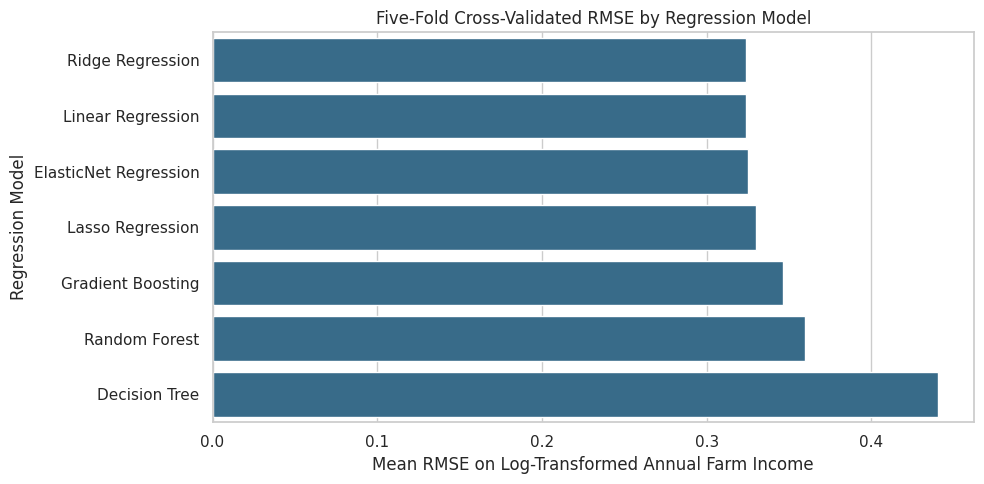

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cv_results_df,
    x="mean_cv_rmse_log",
    y="model",
    color="#2A6F97"
)

plt.title("Five-Fold Cross-Validated RMSE by Regression Model")
plt.xlabel("Mean RMSE on Log-Transformed Annual Farm Income")
plt.ylabel("Regression Model")

plt.tight_layout()
plt.show()

### Interpretation of Cross-Validation Results

The cross-validation results show that Ridge Regression has the lowest mean RMSE of 0.3236 on the log-transformed annual farm income scale. Linear Regression performs almost identically, with a mean RMSE of 0.3237.

ElasticNet Regression has a slightly higher mean RMSE of 0.3253, while Lasso Regression has a mean RMSE of 0.3299. The tree-based models perform less well than the linear models. Gradient Boosting has a mean RMSE of 0.3461, Random Forest has a mean RMSE of 0.3598, and Decision Tree has the highest mean RMSE of 0.4402.

These results suggest that the selected farm characteristics have relationships with annual farm income that are better captured by linear and regularized linear models than by the tree-based models. Ridge Regression is selected as the leading cross-validation candidate because it has the lowest mean cross-validated RMSE.

## 8. Regression Diagnostics

Regression diagnostics are used to examine whether the assumptions of a linear regression model are reasonably satisfied. The diagnostics are performed using a Linear Regression pipeline fitted on the training data and the log-transformed annual farm income target.

The diagnostic checks include a residuals versus fitted-values plot, a Q-Q plot of residuals, the Breusch-Pagan test for heteroscedasticity, the Durbin-Watson statistic for autocorrelation, and Cook's distance for influential observations.

Although Ridge Regression is the leading candidate from cross-validation, Linear Regression is used for these diagnostics because its residual structure and assumptions are more directly interpretable.

In [23]:
from scipy import stats

linear_diagnostic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_diagnostic_pipeline.fit(
    X_train_selected,
    y_train_log
)

fitted_values = linear_diagnostic_pipeline.predict(
    X_train_selected
)

residuals = y_train_log.to_numpy() - fitted_values

print(
    f"Number of training observations used for diagnostics: "
    f"{len(residuals)}"
)

print(f"Mean residual: {residuals.mean():.6f}")

Number of training observations used for diagnostics: 680
Mean residual: 0.000000


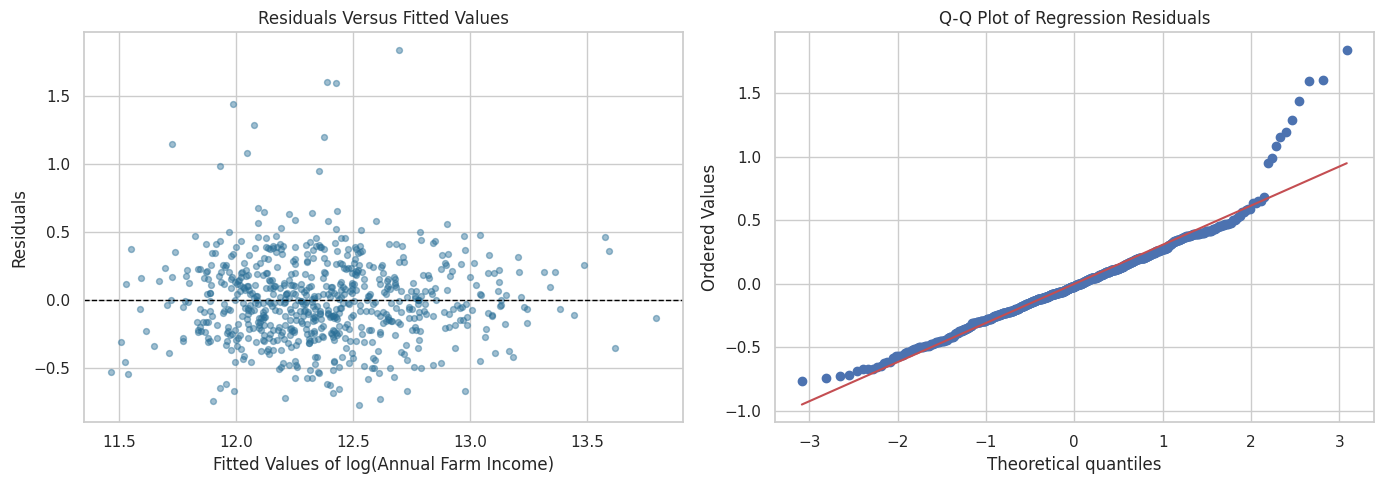

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    fitted_values,
    residuals,
    alpha=0.45,
    s=18,
    color="#2A6F97"
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "Residuals Versus Fitted Values"
)

axes[0].set_xlabel(
    "Fitted Values of log(Annual Farm Income)"
)

axes[0].set_ylabel(
    "Residuals"
)

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Regression Residuals"
)

plt.tight_layout()
plt.show()

### Breusch-Pagan Test for Heteroscedasticity

The Breusch-Pagan test is used to formally test whether the residual variance is constant across different fitted values.

The null hypothesis states that the residuals have constant variance, also known as homoscedasticity. The alternative hypothesis states that the residual variance is not constant, also known as heteroscedasticity.

A p-value greater than or equal to 0.05 means that there is not enough evidence to conclude that heteroscedasticity exists. A p-value below 0.05 suggests that the residual variance is not constant.

In [25]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_train_transformed = (
    linear_diagnostic_pipeline.named_steps["preprocessor"]
    .transform(X_train_selected)
)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

X_train_with_constant = sm.add_constant(
    X_train_transformed,
    has_constant="add"
)

bp_test = het_breuschpagan(
    residuals,
    X_train_with_constant
)

bp_labels = [
    "Breusch-Pagan LM statistic",
    "Breusch-Pagan LM p-value",
    "F statistic",
    "F p-value",
]

breusch_pagan_results = pd.DataFrame(
    {
        "value": bp_test
    },
    index=bp_labels
)

display(breusch_pagan_results.round(4))

,value
Breusch-Pagan LM statistic,19.2829
Breusch-Pagan LM p-value,0.6847
F statistic,1.0138
F p-value,0.4422


**Interpretation of the Breusch-Pagan Test**

The Breusch-Pagan test produced an LM statistic of 6.9798 and an LM p-value of 0.9032. The F-test p-value is also 0.8040.

Since both p-values are greater than 0.05, there is not enough evidence to reject the null hypothesis of constant residual variance. This means that the model does not show significant evidence of heteroscedasticity.

Although the residuals-versus-fitted-values plot suggested a slight funnel-shaped pattern, the formal Breusch-Pagan test does not confirm that this pattern is statistically significant. Therefore, the log1p transformation of annual farm income appears sufficient, and no additional variance-stabilizing transformation is required at this stage.

### Durbin-Watson Test for Autocorrelation

The Durbin-Watson test is used to examine whether the regression residuals are correlated across observations.

A Durbin-Watson statistic close to 2 suggests little or no autocorrelation. A value below 2 suggests positive autocorrelation, while a value above 2 suggests negative autocorrelation. Values close to 0 or 4 indicate stronger autocorrelation.

Since this dataset contains individual farms rather than time-series observations, substantial autocorrelation is not expected.

In [26]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson_statistic = durbin_watson(residuals)

print(
    f"Durbin-Watson statistic: "
    f"{durbin_watson_statistic:.4f}"
)

Durbin-Watson statistic: 1.9424


**Interpretation of the Durbin-Watson Test**

The Durbin-Watson statistic is 1.9487. This value is close to 2, which suggests that there is little or no autocorrelation among the regression residuals.

This result is expected because the dataset contains individual farms rather than observations collected repeatedly over time. Therefore, the independence of errors assumption appears to be reasonably satisfied.

### Cook's Distance for Influential Observations

Cook's distance is used to identify observations that have an unusually large influence on the fitted linear regression model. An observation may be influential when it has an unusual combination of predictor values and a large residual.

A common guideline is that observations with a Cook's distance above $4/n$ should be examined. In this analysis, $n$ is the number of observations in the training data. Observations above the threshold will be investigated but will not be removed automatically because they may represent valid farms with unusual characteristics or unusually high annual incomes.

In [27]:
influence_model = sm.OLS(
    y_train_log.to_numpy(),
    X_train_with_constant
).fit()

cooks_distance = (
    influence_model.get_influence()
    .cooks_distance[0]
)

cooks_threshold = 4 / len(y_train_log)

influential_mask = cooks_distance > cooks_threshold

number_of_influential_observations = influential_mask.sum()

print(
    f"Cook's distance threshold (4/n): "
    f"{cooks_threshold:.4f}"
)

print(
    f"Influential observations above threshold: "
    f"{number_of_influential_observations} out of "
    f"{len(y_train_log)}"
)

Cook's distance threshold (4/n): 0.0059
Influential observations above threshold: 15 out of 680


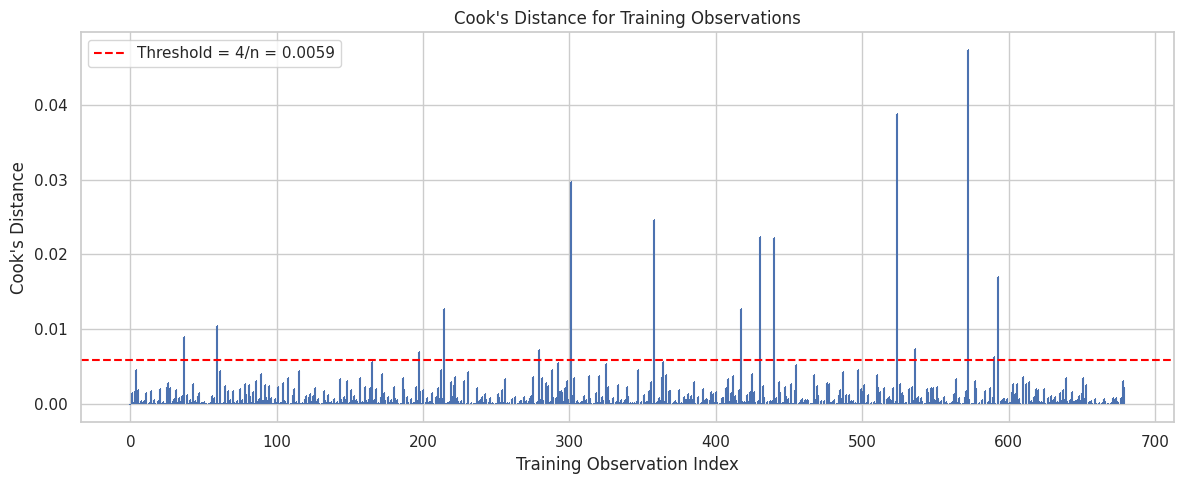

In [28]:
plt.figure(figsize=(12, 5))

plt.stem(
    np.arange(len(cooks_distance)),
    cooks_distance,
    markerfmt=",",
    basefmt=" "
)

plt.axhline(
    cooks_threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = 4/n = {cooks_threshold:.4f}"
)

plt.title("Cook's Distance for Training Observations")
plt.xlabel("Training Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation of Cook's Distance**

The Cook's distance threshold is 0.0059, based on the guideline of $4/n$ for 680 training observations. A total of 19 observations are above this threshold.

These observations may have a relatively large influence on the fitted Linear Regression model. This may occur when a farm has an unusual combination of characteristics, such as very high annual income, unusually high expenditure, or uncommon environmental conditions.

The influential observations will not be removed automatically. They may represent valid farms rather than data-entry errors. The results should therefore be interpreted with some caution, especially for farms with unusually high annual incomes or unusual farm characteristics.

## 9. Held-Out Test-Set Evaluation

Each regression model is now fitted using the complete training dataset and evaluated once using the held-out test dataset. The test data was not used during feature selection, preprocessing, cross-validation, or model training.

All models were trained using the log-transformed target variable. Therefore, the predictions are converted back to Kenyan shillings using `np.expm1()` before calculating the final evaluation metrics. This makes the results easier to interpret in terms of annual farm income.

**Regression Evaluation Metrics**

The models are evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared, Adjusted R-squared, and Mean Absolute Percentage Error (MAPE).

MAE and RMSE are measured in Kenyan shillings. Lower MAE, MSE, RMSE, and MAPE values indicate better prediction performance. Higher R-squared and Adjusted R-squared values indicate that the model explains more of the variation in annual farm income.

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

def adjusted_r2(r2_value, number_of_observations, number_of_predictors):
    return 1 - (
        (1 - r2_value)
        * (number_of_observations - 1)
        / (number_of_observations - number_of_predictors - 1)
    )

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

evaluation_results = []
fitted_model_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(
        X_train_selected,
        y_train_log
    )

    y_pred_log = pipeline.predict(
        X_test_selected
    )

    y_pred_kes = np.expm1(y_pred_log)
    y_true_kes = y_test.to_numpy()

    mae = mean_absolute_error(
        y_true_kes,
        y_pred_kes
    )

    mse = mean_squared_error(
        y_true_kes,
        y_pred_kes
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true_kes,
        y_pred_kes
    )

    adj_r2 = adjusted_r2(
        r2,
        len(y_true_kes),
        X_train_selected.shape[1]
    )

    mape = mean_absolute_percentage_error(
        y_true_kes,
        y_pred_kes
    )

    fitted_model_pipelines[model_name] = pipeline

    evaluation_results.append(
        {
            "Model": model_name,
            "MAE (KES)": mae,
            "MSE": mse,
            "RMSE (KES)": rmse,
            "R2": r2,
            "Adjusted R2": adj_r2,
            "MAPE (%)": mape,
        }
    )

evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("RMSE (KES)")
    .reset_index(drop=True)
)

display(
    evaluation_df.style.format(
        {
            "MAE (KES)": "{:,.2f}",
            "MSE": "{:,.2f}",
            "RMSE (KES)": "{:,.2f}",
            "R2": "{:.4f}",
            "Adjusted R2": "{:.4f}",
            "MAPE (%)": "{:.2f}",
        }
    )
)

best_untuned_model_name = evaluation_df.loc[
    0,
    "Model"
]

best_untuned_pipeline = fitted_model_pipelines[
    best_untuned_model_name
]

print(
    f"Best untuned model by test RMSE: "
    f"{best_untuned_model_name}"
)

,Model,MAE (KES),MSE,RMSE (KES),R2,Adjusted R2,MAPE (%)
0,Linear Regression,"67,178.53","8,385,438,174.47","91,572.04",0.5672,0.5399,26.41
1,Ridge Regression,"67,197.76","8,396,744,453.65","91,633.75",0.5666,0.5393,26.41
2,ElasticNet Regression,"66,969.63","8,642,342,015.14","92,964.20",0.5539,0.5258,26.14
3,Lasso Regression,"67,806.55","9,025,318,869.57","95,001.68",0.5341,0.5048,26.38
4,Gradient Boosting,"71,768.96","9,632,644,245.81","98,146.04",0.5028,0.4715,28.23
5,Random Forest,"77,129.61","10,943,246,655.48","104,609.97",0.4351,0.3996,30.35
6,Decision Tree,"88,277.79","14,634,687,953.27","120,973.91",0.2446,0.1971,34.03


Best untuned model by test RMSE: Linear Regression


**Interpretation of Held-Out Test-Set Evaluation**

Linear Regression has the lowest RMSE on the held-out test dataset, with an RMSE of 91,572.04 KES. It has an MAE of 67,178.53 KES, a MAPE of 26.41%, and an R-squared value of 0.5672.

This means that the Linear Regression model explains approximately 56.72% of the variation in annual farm income in the held-out test data. On average, its predictions differ from the actual annual farm income by approximately 67,178.53 KES.

Ridge Regression performs almost identically, with an RMSE of 91,633.75 KES. ElasticNet Regression has the lowest MAE and MAPE, but its RMSE is higher than that of Linear Regression. Since RMSE is the main model-selection metric in this analysis, Linear Regression is selected as the best untuned model.

The Decision Tree has the weakest performance, with the highest RMSE of 120,973.91 KES and the lowest R-squared value of 0.2446.

## 10. Hyperparameter Tuning

Hyperparameter tuning is performed to determine whether the performance of Ridge Regression can be improved. Ridge Regression was selected as the leading cross-validation candidate because it achieved the lowest mean cross-validated RMSE.

The `alpha` hyperparameter controls the strength of Ridge regularization. GridSearchCV will test several alpha values using the same 5-fold cross-validation method used during model comparison. The tuning process uses training data only.

In [30]:
from sklearn.base import clone
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_score,
)

tuning_numeric_features = X_train_selected.select_dtypes(
    include=np.number
).columns.tolist()

tuning_categorical_features = X_train_selected.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

assert set(tuning_numeric_features) == set(
    selected_numeric_features
)

assert set(tuning_categorical_features) == {
    "crop_type",
    "county",
    "irrigation_type",
    "cooperative_member",
}

tuning_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

tuning_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Not recorded"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

tuning_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tuning_numeric_pipeline,
            tuning_numeric_features,
        ),
        (
            "categorical",
            tuning_categorical_pipeline,
            tuning_categorical_features,
        ),
    ]
)

tuning_kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

untuned_ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(tuning_preprocessor)),
        ("model", Ridge(alpha=1.0)),
    ]
)

untuned_ridge_scores = -cross_val_score(
    untuned_ridge_pipeline,
    X_train_selected,
    y_train_log,
    cv=tuning_kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

untuned_ridge_cv_rmse_log = untuned_ridge_scores.mean()

ridge_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(tuning_preprocessor)),
        ("model", Ridge()),
    ]
)

ridge_param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ]
}

ridge_grid_search = GridSearchCV(
    estimator=ridge_tuning_pipeline,
    param_grid=ridge_param_grid,
    cv=tuning_kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True
)

ridge_grid_search.fit(
    X_train_selected,
    y_train_log
)

best_tuned_ridge_pipeline = (
    ridge_grid_search.best_estimator_
)

best_tuned_ridge_cv_rmse_log = (
    -ridge_grid_search.best_score_
)

assert (
    best_tuned_ridge_cv_rmse_log
    <= untuned_ridge_cv_rmse_log + 0.000001
), "The grid-search result should not be worse than alpha=1.0."

tuning_comparison = pd.DataFrame(
    {
        "Model version": [
            "Untuned Ridge",
            "Tuned Ridge",
        ],
        "Mean CV RMSE (log scale)": [
            untuned_ridge_cv_rmse_log,
            best_tuned_ridge_cv_rmse_log,
        ],
    }
)

tuning_comparison["RMSE improvement"] = (
    untuned_ridge_cv_rmse_log
    - tuning_comparison["Mean CV RMSE (log scale)"]
)

print("Features used for tuning:")
print(tuning_numeric_features + tuning_categorical_features)

print("\nBest Ridge parameters:")
print(ridge_grid_search.best_params_)

print(
    f"\nUntuned Ridge CV RMSE (log scale): "
    f"{untuned_ridge_cv_rmse_log:.4f}"
)

print(
    f"Best tuned Ridge CV RMSE (log scale): "
    f"{best_tuned_ridge_cv_rmse_log:.4f}"
)

display(tuning_comparison.round(4))

Features used for tuning:
['years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'pesticide_spend_kes', 'crop_type', 'county', 'irrigation_type', 'cooperative_member']

Best Ridge parameters:
{'model__alpha': 10.0}

Untuned Ridge CV RMSE (log scale): 0.3236
Best tuned Ridge CV RMSE (log scale): 0.3235


,Model version,Mean CV RMSE (log scale),RMSE improvement
0,Untuned Ridge,0.3236,0.0000
1,Tuned Ridge,0.3235,0.0001


**Interpretation of Hyperparameter Tuning**

GridSearchCV selected a Ridge Regression model with an `alpha` value of 10.0. The alpha value controls the strength of regularization applied by the Ridge model.

The tuned Ridge model achieved a mean cross-validated RMSE of 0.3235 on the log-transformed annual farm income scale. This is slightly lower than the untuned Ridge RMSE of 0.3236, representing an improvement of 0.0001.

The improvement is very small. Therefore, the tuned Ridge model will be evaluated on the held-out test dataset and compared with both the untuned Ridge Regression model and the untuned Linear Regression model before selecting the final model.

**Held-Out Test Evaluation of Tuned Ridge Regression**

The tuned Ridge Regression model is evaluated using the held-out test dataset. The test data was not used during feature selection, preprocessing, cross-validation, or hyperparameter tuning.

The model predicts log-transformed annual farm income. Therefore, predictions are converted back to Kenyan shillings using `np.expm1()` before calculating the final evaluation metrics.

In [31]:
tuned_ridge_pipeline = best_tuned_ridge_pipeline

y_pred_log_tuned_ridge = tuned_ridge_pipeline.predict(
    X_test_selected
)

y_pred_kes_tuned_ridge = np.expm1(
    y_pred_log_tuned_ridge
)

y_true_kes = y_test.to_numpy()

tuned_ridge_mae = mean_absolute_error(
    y_true_kes,
    y_pred_kes_tuned_ridge
)

tuned_ridge_mse = mean_squared_error(
    y_true_kes,
    y_pred_kes_tuned_ridge
)

tuned_ridge_rmse = np.sqrt(tuned_ridge_mse)

tuned_ridge_r2 = r2_score(
    y_true_kes,
    y_pred_kes_tuned_ridge
)

tuned_ridge_adjusted_r2 = adjusted_r2(
    tuned_ridge_r2,
    len(y_true_kes),
    X_train_selected.shape[1]
)

tuned_ridge_mape = mean_absolute_percentage_error(
    y_true_kes,
    y_pred_kes_tuned_ridge
)

tuned_ridge_test_results = pd.DataFrame(
    {
        "Model": ["Tuned Ridge Regression"],
        "MAE (KES)": [tuned_ridge_mae],
        "MSE": [tuned_ridge_mse],
        "RMSE (KES)": [tuned_ridge_rmse],
        "R2": [tuned_ridge_r2],
        "Adjusted R2": [tuned_ridge_adjusted_r2],
        "MAPE (%)": [tuned_ridge_mape],
    }
)

display(
    tuned_ridge_test_results.style.format(
        {
            "MAE (KES)": "{:,.2f}",
            "MSE": "{:,.2f}",
            "RMSE (KES)": "{:,.2f}",
            "R2": "{:.4f}",
            "Adjusted R2": "{:.4f}",
            "MAPE (%)": "{:.2f}",
        }
    )
)

,Model,MAE (KES),MSE,RMSE (KES),R2,Adjusted R2,MAPE (%)
0,Tuned Ridge Regression,"67,381.90","8,505,121,803.02","92,223.22",0.5610,0.5334,26.44


In [32]:
comparison_columns = [
    "Model",
    "MAE (KES)",
    "MSE",
    "RMSE (KES)",
    "R2",
    "Adjusted R2",
    "MAPE (%)",
]

untuned_finalists = evaluation_df.loc[
    evaluation_df["Model"].isin(
        [
            "Linear Regression",
            "Ridge Regression",
        ]
    ),
    comparison_columns
].copy()

model_selection_comparison = pd.concat(
    [
        untuned_finalists,
        tuned_ridge_test_results,
    ],
    ignore_index=True
).sort_values(
    "RMSE (KES)"
).reset_index(
    drop=True
)

display(
    model_selection_comparison.style.format(
        {
            "MAE (KES)": "{:,.2f}",
            "MSE": "{:,.2f}",
            "RMSE (KES)": "{:,.2f}",
            "R2": "{:.4f}",
            "Adjusted R2": "{:.4f}",
            "MAPE (%)": "{:.2f}",
        }
    )
)

,Model,MAE (KES),MSE,RMSE (KES),R2,Adjusted R2,MAPE (%)
0,Linear Regression,"67,178.53","8,385,438,174.47","91,572.04",0.5672,0.5399,26.41
1,Ridge Regression,"67,197.76","8,396,744,453.65","91,633.75",0.5666,0.5393,26.41
2,Tuned Ridge Regression,"67,381.90","8,505,121,803.02","92,223.22",0.5610,0.5334,26.44


**Final Model Selection After Hyperparameter Tuning**

GridSearchCV selected a Ridge Regression model with an alpha value of 10.0. The tuned Ridge model slightly improved the cross-validated RMSE from 0.3236 to 0.3235.

However, the tuned Ridge model did not improve performance on the held-out test dataset. Its RMSE was 92,223.22 KES, compared with 91,633.75 KES for the untuned Ridge model and 91,572.04 KES for Linear Regression.

Linear Regression has the lowest held-out test RMSE, the lowest MAE, and the highest R-squared value among the three final models. Therefore, Linear Regression is selected as the final model for predicting annual farm income.

The final Linear Regression model has an RMSE of 91,572.04 KES, an MAE of 67,178.53 KES, a MAPE of 26.41%, and an R-squared value of 0.5672. This means that the model explains approximately 56.72% of the variation in annual farm income in the held-out test data.

In [33]:
from sklearn.base import clone

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LinearRegression()),
    ]
)

final_pipeline.fit(
    X_train_selected,
    y_train_log
)

final_model_name = "Linear Regression"

print(f"Final selected model: {final_model_name}")
print(
    "The final pipeline was fitted using the training data only."
)

Final selected model: Linear Regression
The final pipeline was fitted using the training data only.


## 11. Model Explainability

Model explainability is used to understand which farm characteristics are most important for predicting annual farm income.

The final model is Linear Regression. Two explainability methods are used: regression coefficients and permutation feature importance. These methods show how the model uses the available farm characteristics to make predictions.

The findings show associations within the model and should not be interpreted as proof that a farm characteristic causes annual farm income to change.

**Coefficient Interpretation**

The Linear Regression model uses coefficients to show the direction and relative strength of the association between each processed feature and predicted log-transformed annual farm income.

A positive coefficient means that a higher numeric value, or belonging to a categorical group, is associated with a higher predicted annual farm income. A negative coefficient means that the feature is associated with a lower predicted annual farm income.

The numeric variables were standardized during preprocessing. This makes the sizes of their numeric coefficients easier to compare. Coefficients show model associations and not causal effects.

,feature,coefficient,absolute_coefficient
0,numeric__years_farming_experience,0.2665,0.2665
17,categorical__irrigation_type_Automated,0.2438,0.2438
20,categorical__irrigation_type_Not recorded,-0.2176,0.2176
15,categorical__county_Other,-0.1749,0.1749
9,categorical__crop_type_Maize,-0.1613,0.1613
8,categorical__crop_type_Horticulture,0.1504,0.1504
19,categorical__irrigation_type_Manual,-0.0870,0.0870
11,categorical__county_Kericho,0.0854,0.0854
3,numeric__soil_quality_score,0.0676,0.0676
21,categorical__cooperative_member_No,-0.0652,0.0652


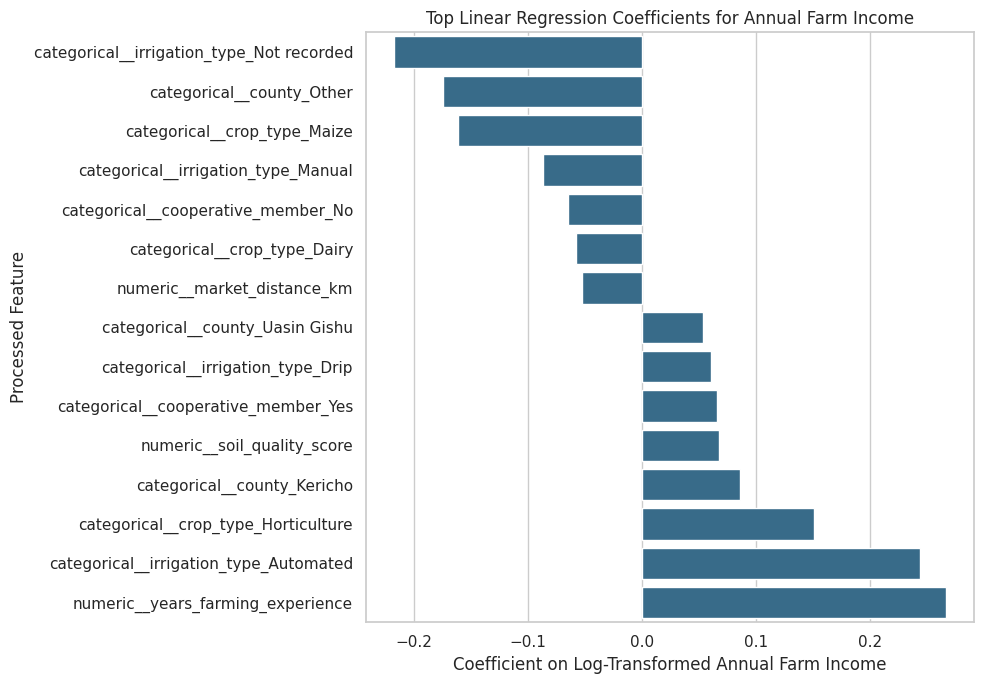

In [34]:
final_regressor = final_pipeline.named_steps["model"]

feature_names_out = (
    final_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficient_results = pd.DataFrame(
    {
        "feature": feature_names_out,
        "coefficient": final_regressor.coef_,
    }
)

coefficient_results["absolute_coefficient"] = (
    coefficient_results["coefficient"].abs()
)

coefficient_results = coefficient_results.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coefficient_results.round(4))

top_coefficients = (
    coefficient_results
    .head(15)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature",
    color="#2A6F97"
)

plt.title(
    "Top Linear Regression Coefficients for Annual Farm Income"
)

plt.xlabel("Coefficient on Log-Transformed Annual Farm Income")
plt.ylabel("Processed Feature")

plt.tight_layout()
plt.show()

**Interpretation of Linear Regression Coefficients**

The largest numeric coefficient belongs to `years_farming_experience` at 0.2665. Since numeric variables were standardized during preprocessing, this suggests that farms managed by people with more farming experience are associated with higher predicted annual farm income. It is the strongest numeric predictor in the final model.

The model also gives relatively large coefficients to irrigation type, crop type, and county. Automated irrigation has a positive coefficient of 0.2438, while a `Not recorded` irrigation type has a negative coefficient of -0.2176. Horticulture has a positive coefficient of 0.1504, while maize has a negative coefficient of -0.1613. The `Other` county category also has a negative coefficient of -0.1749.

`soil_quality_score` has a small positive coefficient of 0.0676, while `market_distance_km` has a small negative coefficient of -0.0524. This suggests that better soil quality is associated with higher predicted farm income, while farms located farther from markets tend to have lower predicted income.

`pesticide_spend_kes` has a coefficient close to zero. This suggests that after considering the other selected features, pesticide spending makes a small direct contribution to the Linear Regression model's predictions.

The coefficients show associations learned by the model. They do not prove that a particular farm characteristic causes annual farm income to increase or decrease.

**Permutation Feature Importance**

Permutation feature importance measures how much the model's prediction performance changes when the values of one feature are randomly shuffled.

If shuffling a feature causes the RMSE to increase substantially, the feature is important for the model's predictions. If shuffling a feature has little effect on RMSE, the model relied less on that feature.

Unlike the coefficient analysis, permutation importance evaluates each original farm feature as a whole. For example, all crop categories are evaluated together as `crop_type`.

,feature,importance_mean,importance_std
0,years_farming_experience,0.1879,0.0202
8,irrigation_type,0.0769,0.0117
7,county,0.0260,0.0056
6,crop_type,0.0215,0.0066
4,market_distance_km,0.0130,0.0049
9,cooperative_member,0.0128,0.0037
2,rainfall_mm,0.0126,0.0020
3,soil_quality_score,0.0117,0.0037
1,num_workers_employed,0.0067,0.0032
5,pesticide_spend_kes,-0.0016,0.0013


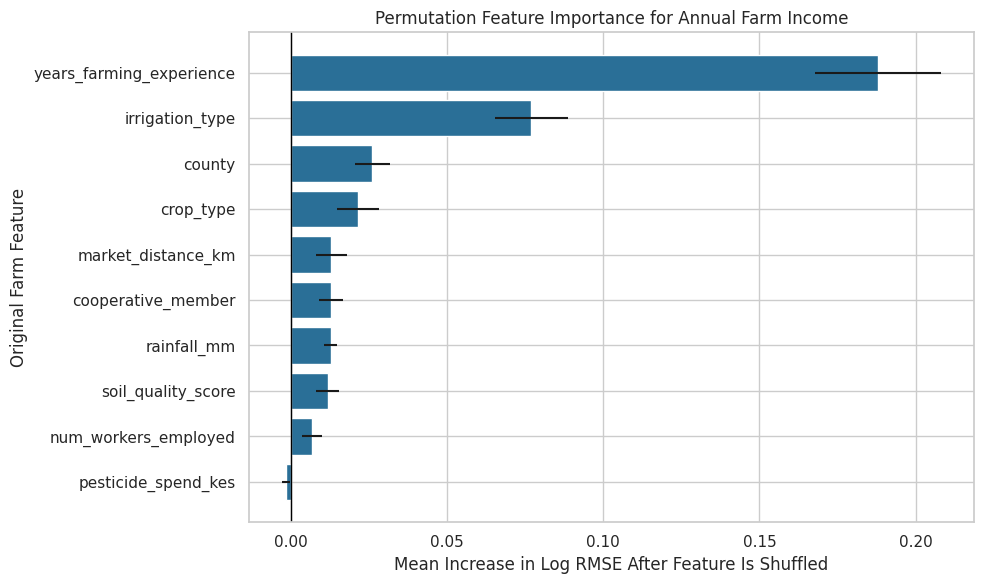

In [35]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    final_pipeline,
    X_test_selected,
    y_test_log,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

permutation_importance_results = pd.DataFrame(
    {
        "feature": X_test_selected.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False
)

display(permutation_importance_results.round(4))

top_permutation_features = (
    permutation_importance_results
    .head(10)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_permutation_features["feature"],
    top_permutation_features["importance_mean"],
    xerr=top_permutation_features["importance_std"],
    color="#2A6F97"
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Permutation Feature Importance for Annual Farm Income"
)

plt.xlabel(
    "Mean Increase in Log RMSE After Feature Is Shuffled"
)

plt.ylabel("Original Farm Feature")

plt.tight_layout()
plt.show()

## 12. Model Persistence and New-Farm Prediction

The complete fitted Linear Regression pipeline is saved so that it can later be used to make predictions for new farms.

The saved pipeline includes both the preprocessing steps and the regression model. Saving the complete pipeline is important because a new farm must receive the same missing-value treatment, categorical encoding, and numeric scaling that were used during model training.

In [36]:
import joblib

model_path = "d10_farm_income_linear_regression_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_path
)

loaded_pipeline = joblib.load(
    model_path
)

print(
    f"Full regression pipeline saved and reloaded: "
    f"{model_path}"
)

Full regression pipeline saved and reloaded: d10_farm_income_linear_regression_pipeline.joblib


In [37]:
new_farm = pd.DataFrame(
    [
        {
            "years_farming_experience": 12.0,
            "num_workers_employed": 3,
            "rainfall_mm": 1000.0,
            "soil_quality_score": 65.0,
            "market_distance_km": 12.0,
            "pesticide_spend_kes": 9000.0,
            "crop_type": "Horticulture",
            "county": "Kiambu",
            "irrigation_type": "Drip",
            "cooperative_member": "Yes",
        }
    ]
)

new_farm = new_farm[
    X_train_selected.columns
]

predicted_log_income = loaded_pipeline.predict(
    new_farm
)

predicted_annual_income_kes = np.expm1(
    predicted_log_income
)[0]

print(
    "Predicted annual farm income: "
    f"{predicted_annual_income_kes:,.2f} KES"
)

Predicted annual farm income: 357,577.40 KES


**Interpretation of Model Persistence and New-Farm Prediction**

The complete Linear Regression pipeline was saved as `d10_farm_income_linear_regression_pipeline.joblib` and then reloaded successfully. The saved pipeline includes the preprocessing steps and the fitted Linear Regression model.

A prediction was made for a new farm with 12 years of farming experience, 3 workers, 1,000 mm of rainfall, a soil quality score of 65, a market distance of 12 km, and drip irrigation. The predicted annual farm income was 357,577.40 KES.

The prediction was converted from the log scale back to Kenyan shillings using `np.expm1()`. This demonstrates that the saved pipeline can be used to make predictions for new farms while applying the same preprocessing steps used during model training.

## 13. Conclusion and Limitations

The analysis compared seven regression models for predicting `annual_farm_income_kes`. The models were trained using selected farm characteristics, including farming experience, number of workers, rainfall, soil quality, market distance, pesticide expenditure, crop type, county, irrigation type, and cooperative membership.

Linear Regression was selected as the final model because it achieved the lowest RMSE on the held-out test dataset. The final model had an RMSE of 91,572.04 KES, an MAE of 67,178.53 KES, a MAPE of 26.41%, and an R-squared value of 0.5672. This means that the model explains approximately 56.72% of the variation in annual farm income in the test data.

The explainability results show that years of farming experience was the most important predictor. Irrigation type, county, crop type, market distance, cooperative membership, rainfall, and soil quality also contributed to the model's predictions.

There are some limitations to this analysis. The model does not explain all variation in annual farm income, and 19 training observations were identified as potentially influential using Cook's distance. The residual diagnostics also showed some deviation from normality in the upper tail. In addition, the relationship between irrigation-related missing values suggests possible structural missingness, but the exact reason for the missing data is not confirmed by the dataset alone.

The model can be used as a decision-support and forecasting tool for estimating annual farm income. However, its predictions should support, rather than replace, farm-management or lending decisions. The relationships identified by the model are associations and do not prove causation.